In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib

import ipywidgets as widgets
from IPython.display import display
import trimesh
from torch import autograd as Grad
import random
import math
import pyrender


In [2]:
# Function to compute barycentric coordinates
def barycentric_coordinates(points, tri):
    """
    Compute barycentric coordinates for a set of points w.r.t. a given triangle.
    """
    A = np.hstack([tri, np.ones((3, 1))])  # Homogeneous coordinates
    inv_A = np.linalg.inv(A)  # Inverse of transformation matrix
    points_homo = np.hstack([points, np.ones((points.shape[0], 1))])  # Convert points to homogeneous
    bary_coords = points_homo @ inv_A.T  # Compute barycentric coordinates
    
    return bary_coords  # Shape: (num_points, 3)

    

    
def blend_func1d(x,v=0.5):

    result = torch.zeros_like(x)  
    mask = torch.abs(x) < (1+v)/2
    temp = (1+v)**2
    result[mask] = torch.exp(1 + (temp / (4*x[mask]**2 - temp)))
    
    return result




def blend_func2d(x):
    # a blend function on the coarse parametrisation neighbourhood
    # neighbourhood is like this:
    #       *
    #     ' | '
    #   *---*---*
    #     ' | '
    #       *
    r = torch.sqrt(x.pow(2).sum(-1)).unsqueeze(-1)
    #print('r shape', r.shape)
    return blend_func1d(r)




def transition(x, i,j):
    
    #r = torch.sqrt(x.pow(2).sum(-1))
    #theta = torch.atan2(x[:,1], x[:,0])
    pt = np.array([[0.0, 1.0],
                  [-1.0, 0.0],
                  [0.0, -1.0],
                  [1.0, 0.0]])

    v = x-pt[i]
    r = torch.sqrt(v.pow(2).sum(-1))
    theta = torch.atan2(v[:,1], v[:,0]) 

    theta += i*torch.pi/2
    new_theta = 2*theta + j*torch.pi/2
    
    out = torch.stack([r*torch.cos(new_theta), r*torch.sin(new_theta)]).transpose(0,1).float()
    

    #plt.plot(theta/ (2*torch.pi) )
    #plt.show()
    #print(theta)
    return out, theta





        









class MLP(nn.Module):
	def __init__(self, layer_sizes):
		super(MLP, self).__init__()
		layers = []
		for i in range(len(layer_sizes) - 1):
			layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
			if i < len(layer_sizes) - 2:  # No activation on last layer
				layers.append(nn.Tanh())
		self.network = nn.Sequential(*layers)

        
	
	def forward(self, x):
		return self.network(x)

class BlendedMLP(nn.Module):
    def __init__(self, n, layer_sizes, coarse_points):
        super(BlendedMLP, self).__init__()
        self.mlps = nn.ModuleList([MLP(layer_sizes) for _ in range(n)])
        self.coarse_points = coarse_points
        self.my_transitions = {0: { 2:(1,0), 3:(3,0), 5:(2,0), 4:(0,0) },
                            1: { 2:(1,2), 3:(3,2), 5:(0,2), 4:(2,2) },
                            2: { 0:(0,1), 4:(1,3), 1:(2,1), 5:(3,1) },
                            3: { 0:(0,3), 4:(3,1), 1:(2,3), 5:(1,3) },
                            4: { 0:(0,0), 3:(1,3), 1:(2,2), 2:(3,1) },
                            5: { 0:(0,2), 3:(3,1), 1:(2,0), 2:(1,3) }}

        
        self.n = n
        self.weights = [1 for i in range(n)]
        self.rotations = [torch.eye(3) for i in range(n)]

        #self.fake_mlps = [lambda x: (torch.rand(1) + torch.sin(5*x)+2)*torch.stack([torch.cos(x), torch.sin(x)]).squeeze().transpose(0,1) for _ in range(n)]


    def component(self, x, i):
        
        #return (self.weights[i] * self.mlps[i](x)@self.rotations[i]  + self.coarse_points[i] ) * blend_func(x)
        return (self.weights[i] * 0* self.mlps[i](x)@self.rotations[i]  + self.coarse_points[i] ) * blend_func2d(x)
        
       
    def forward(self, x):
        components = []
        for i in range(self.n):
            con = self.my_transitions[i]
            component=self.component(x,i)
            for c in con.keys():
                component += self.component(transition(x,con[c][0], con[c][1])[0], c)
            components.append(component)

        #return torch.stack([ (self.component(x,i) + self.component())           ]) 
        #return torch.stack([ ( self.component(x,i) + self.component(x+1,(i-1)%self.n) + self.component(x-1, (i+1)%self.n )) for i in range(self.n) ]).transpose(1,0)
        #return torch.stack([ self.component(x,i)  for i in range(self.n) ]).transpose(1,0)

        out = torch.stack(components).transpose(1,0)
        #print(out.shape)
        
        return out
        
        
      





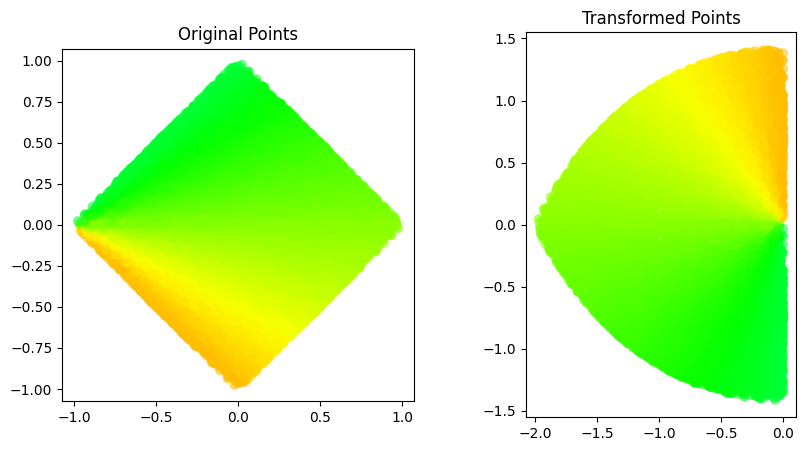

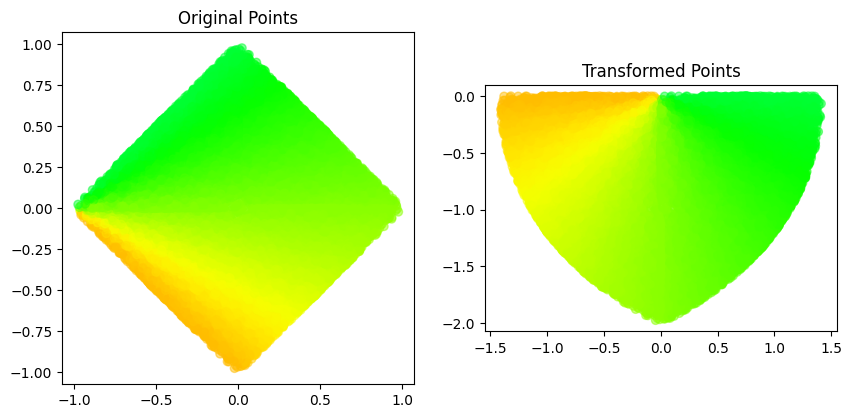

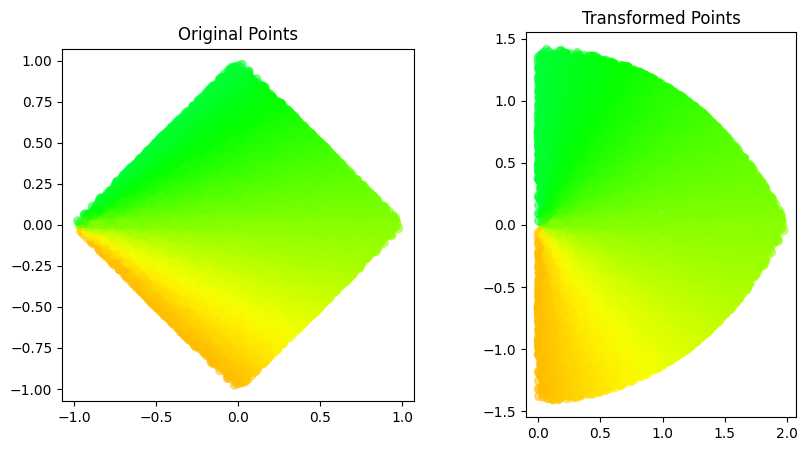

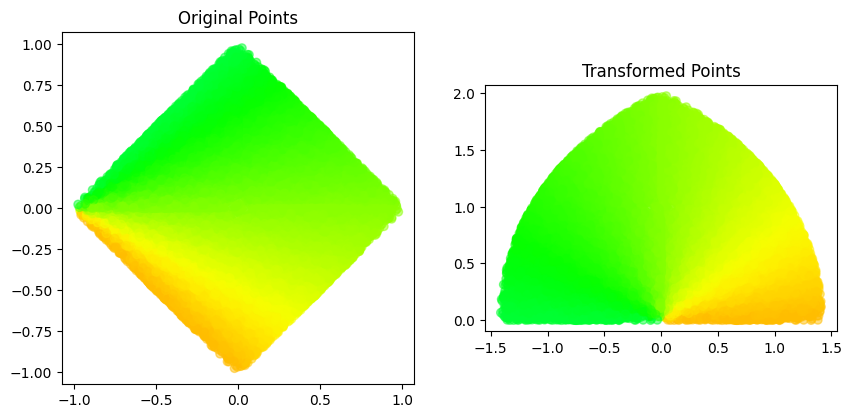

In [4]:
p = t_train[:40000,:]


for j in range(4):
    
    
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Given triangle vertices
    tri_vertices = np.array([[-1, 0], [1, 0], [0, 1]])
    
    bary_coords = barycentric_coordinates(p, tri_vertices)
    
    out, theta = transition(p, 1,j)

    theta = theta*(theta>=0) + (theta+2*torch.pi)*(theta<0)
    colors = matplotlib.cm.hsv(theta/(2*torch.pi))
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax in axes:
        ax.set_aspect('equal')
    
    axes[0].scatter(p[:, 0], p[:, 1], c=colors, alpha=0.5)
    axes[0].set_title("Original Points")
    
    axes[1].scatter(out[:, 0], out[:, 1], c=colors, alpha=0.5)
    axes[1].set_title("Transformed Points")
    
    plt.show()




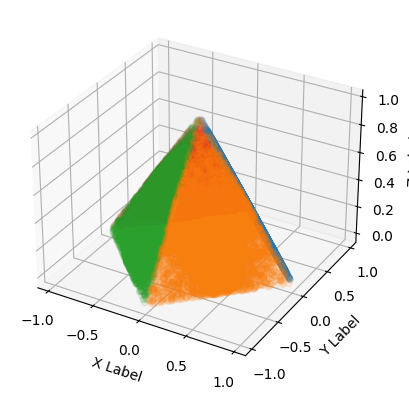

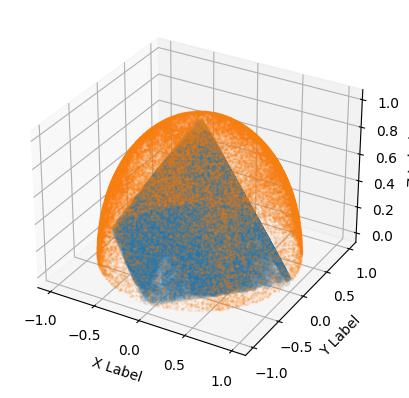

In [3]:

layer_sizes = [2, 16, 16, 3]  # Example structure: 2 input, two hidden layers (16 neurons), 3 output
n=6

blended_mlp = BlendedMLP(n, layer_sizes, coarse_points=torch.zeros(n,3))
# Training all models jointly
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.05)




temp = torch.rand(10000, 3)  # Sample from uniform [0,1]^2

temp_sum = temp.sum(1)

x = temp[:, 0]/temp_sum
y = temp[:, 1]/temp_sum
z = (1-x-y)


coarse_nbhd_sep = torch.stack([ torch.stack([x,y,z]), torch.stack([y,-x,z]),torch.stack([-x,-y,z]), torch.stack([-y,x,z]) ] )
coarse_nbhd = coarse_nbhd_sep.permute(0, 2, 1).reshape(-1,3)

t_train = coarse_nbhd[:,:2]





import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(coarse_nbhd_sep[0,0,:], coarse_nbhd_sep[0,1,:], coarse_nbhd_sep[0,2,:], marker='o', alpha=0.1)
ax.scatter(coarse_nbhd_sep[1,0,:], coarse_nbhd_sep[1,1,:], coarse_nbhd_sep[1,2,:], marker='o', alpha=0.1)
ax.scatter(coarse_nbhd_sep[2,0,:], coarse_nbhd_sep[2,1,:], coarse_nbhd_sep[2,2,:], marker='o', alpha=0.1)
ax.scatter(coarse_nbhd_sep[3,0,:], coarse_nbhd_sep[3,1,:], coarse_nbhd_sep[3,2,:], marker='o', alpha=0.1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')



plt.show()


target_train = coarse_nbhd/ np.linalg.norm(coarse_nbhd, axis=1, keepdims=True)

x = target_train[:,0]
y = target_train[:,1]
z = target_train[:,2]

target_train = torch.stack([torch.stack([x,y,z]), #top
                           torch.stack([-x,y, -z]), #bottom
                           torch.stack([-z , y, x]), #left
                           torch.stack([z , y, -x]), #right
                           torch.stack([x , z, -y]), #back
                           torch.stack([x , -z, y])] ).permute(2,0,1) # front


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(coarse_nbhd[:,0], coarse_nbhd[:,1], coarse_nbhd[:,2], marker='o', alpha=0.1)
ax.scatter(target_train[:,0,0], target_train[:,0,1], target_train[:,0,2], marker='o', alpha=0.1, s=1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')



plt.show()



In [5]:

def show_output(output):
    
    scene = pyrender.Scene()
    colors = np.array([
    [1.0, 0.0, 0],  # Red
    [0, 1, 0],  # Green
    [0, 0, 1],  # Blue
    [1, 1, 0],  # Yellow
    [1, 0, 1],  # Magenta
    [0, 1, 1],  # Cyan
])

    
    # Iterate over the 6 point clouds
    for i in range(6):
        # Extract points for the current cloud (Shape: [40000, 3])
        points = output[:, i, :].detach().numpy()
    
        # Create a trimesh point cloud
        cloud = trimesh.PointCloud(points)
    
        # Convert to pyrender mesh
        cloud_pyrender = pyrender.Mesh.from_points(points, colors=np.tile(colors[i], (points.shape[0], 1)))
        cloud_pyrender.color = 'blue'
    
        # Add to scene
        scene.add(cloud_pyrender)
    
    # Add a light source
    light = pyrender.DirectionalLight(color=np.ones(3), intensity=2.0)
    scene.add(light)
    
    # Create a viewer
    viewer = pyrender.Viewer(scene, use_raymond_lighting=True, point_size=2)

In [6]:
epoch=0

In [7]:
%matplotlib inline

# Training loop
for _ in range(1000):
    optimizer.zero_grad()
    output_train = blended_mlp(t_train)
    #loss = criterion(output_train, target_train)
    #print(output_train.shape)
    #print(target_train.shape)
    loss = (output_train-target_train).pow(2).mean()
    loss.backward()
    optimizer.step()

    # Corrected indentation for if condition
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    #if epoch%100 ==0:
    #    show_output(output_train)
        
    
    epoch += 1  # Increment epoch counter


Epoch 0, Loss: 0.3333
Epoch 10, Loss: 0.3333


KeyboardInterrupt: 

In [ ]:
output_train.shape

In [ ]:
target_train.shape

In [ ]:
output_train.shape

In [ ]:
import torch
import trimesh
import numpy as np

# Example tensor (Replace with your actual data)
point_clouds = output_train

# Iterate over the 6 point clouds
for i in range(6):
    # Extract points for the current cloud (Shape: [40000, 3])
    points = point_clouds[:, i, :].detach().numpy()

    # Create a Trimesh point cloud
    cloud = trimesh.PointCloud(points)

    # Save as .ply file
    filename = f"pointcloud_{i}.ply"
    cloud.export(filename)
    print(f"Saved: {filename}")


In [ ]:
show_output(output_train)